# Function 5 – Next Evaluation (Week 7)

Load all observed data, identify the current maximum (incumbent), run exploitative Bayesian Optimization (β=0), and save the suggested next point.

In [1]:
import numpy as np
from pathlib import Path

import sys
sys.path.append('../..')

from scripts.utils.data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    _load_latest_week_data,
    plot_tsne_with_distribution,
)

from scripts.bayesian_optimisation import SimpleBayesianOptimization

base_dir = Path('../../data/initial_data')
week1_dir = Path('../../data/week1')
week2_dir = Path('../../data/week2')
week3_dir = Path('../../data/week3')
week4_dir = Path('../../data/week4')
week5_dir = Path('../../data/week5')
week6_dir = Path('../../data/week6')

initial_data = load_initial_data(base_dir)
week1_data = load_week1_data(week1_dir)
week2_data = load_week2_data(week2_dir)
week3_data = load_week3_data(week3_dir)
week4_data = load_week4_data(week4_dir)
week5_data = _load_latest_week_data(week5_dir, 'Week 5')
week6_data = _load_latest_week_data(week6_dir, 'Week 6')

function_name = 'function_5'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']
week5_input = week5_data[function_name]['input']
week5_output = week5_data[function_name]['output']
week6_input = week6_data[function_name]['input']
week6_output = week6_data[function_name]['output']

X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1),
    week5_input.reshape(1, -1),
    week6_input.reshape(1, -1),
])
y_observed = np.concatenate([
    original_outputs,
    np.array([week1_output, week2_output, week3_output, week4_output, week5_output, week6_output]),
])

best_idx = np.argmax(y_observed)
incumbent_input = X_observed[best_idx]
incumbent_output = y_observed[best_idx]

print('=' * 60)
print('FUNCTION 5 – CURRENT MAXIMUM (INCUMBENT)')
print('=' * 60)
print(f'Incumbent input (best-performing configuration): {incumbent_input}')
print(f'Incumbent output (observed maximum):            {incumbent_output:.6f}')
print(f'Number of observations:                         {len(y_observed)}')
print('=' * 60)


FUNCTION 5 – CURRENT MAXIMUM (INCUMBENT)
Incumbent input (best-performing configuration): [0.937239 0.959791 0.960767 0.818897]
Incumbent output (observed maximum):            4219.157963
Number of observations:                         26


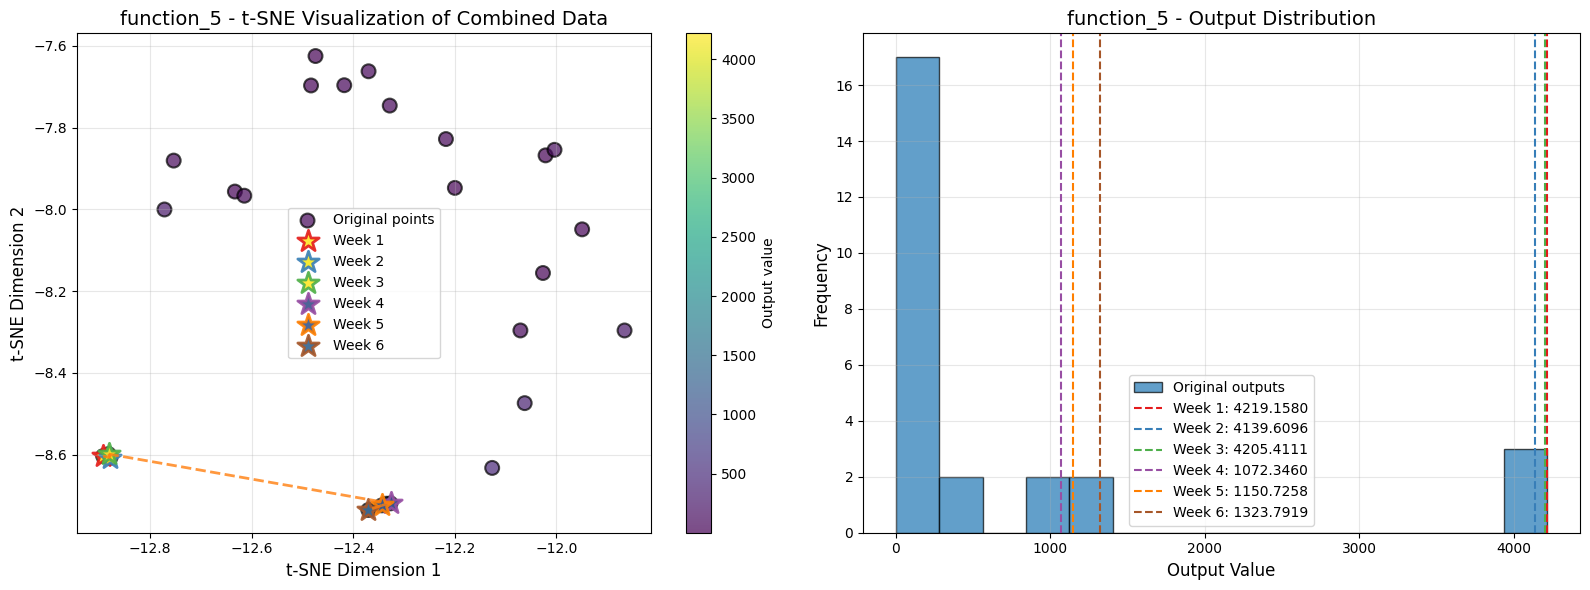

In [2]:
# Visualise past results: show all week 1–6 points before deciding on next evaluation
plot_tsne_with_distribution(
    X_observed, y_observed,
    week6_input, week6_output,
    function_name,
    weekly_points=[
        (week1_input, week1_output, "Week 1"),
        (week2_input, week2_output, "Week 2"),
        (week3_input, week3_output, "Week 3"),
        (week4_input, week4_output, "Week 4"),
        (week5_input, week5_output, "Week 5"),
        (week6_input, week6_output, "Week 6"),
    ],
    connect_points=True,
    connect_color="tab:orange",
    random_state=42
)

In [3]:
# Run exploitative BO (β=0) and suggest next point
n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

bo = SimpleBayesianOptimization(bounds=bounds, n_initial=0, random_state=42)
bo.fit(X_observed, y_observed)
next_point = bo.suggest_next_point(beta=0.0)
ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=0.0)[0]

formatted_point = '-'.join([f'{x:.6f}' for x in next_point])

print('=' * 60)
print('FUNCTION 5 – EXPLOITATIVE BO SUGGESTION (β=0)')
print('=' * 60)
print(f'Suggested next point: {formatted_point}')
print(f'Expected value (UCB = mean): {ucb_value:.6f}')
print('=' * 60)


FUNCTION 5 – EXPLOITATIVE BO SUGGESTION (β=0)
Suggested next point: 0.251719-0.842217-0.941979-0.886140
Expected value (UCB = mean): 1386.679079


/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Approach for Next Evaluation (Function 5 – Exploitative BO)

For the next evaluation, we use **exploitative Bayesian Optimization** (GP + UCB with β=0): the suggested point is the one that **maximises the GP posterior mean**, i.e. where the surrogate model predicts the highest objective value.

---

### Why this approach

Function 5 is treated as a **deterministic or low-noise** objective. Under that assumption:

- The GP surrogate is a reliable predictor of the objective.
- **Exploitation** (β=0) focuses on refining the best region rather than exploring uncertain areas.
- The next point is chosen to maximise predicted performance.

---

### What we are doing

We **evaluate the objective at the BO-suggested point** above. This continues the exploitative strategy from Week 6 and updates the surrogate with the new observation for the next iteration.

In [ ]:
# Save to results/ in same format as function1_next_point.json
import json

result = {
    "function_name": function_name,
    "next_point": next_point.tolist(),
    "formatted": formatted_point,
    "method": "bayesian_optimization_exploitative",
}
Path("results").mkdir(exist_ok=True)
output_path = Path("results/function5_next_point.json")
with open(output_path, "w") as f:
    json.dump(result, f, indent=2)

print('Next evaluation point (BO suggestion):', formatted_point)
print('Input vector:', next_point)
print(f"\nResult saved to: {output_path}")


Next evaluation point (BO suggestion): 0.251719-0.842217-0.941979-0.886140
Input vector: [0.2517192  0.84221653 0.94197894 0.88614041]

Result saved to: results/function5_next_point.json
